# Return-channel encoding: distribution, code-space usage, and quantile coding

The `return_variance` feature set encodes the **log return** (`feats[:, 2]`, `log(x[t]/x[t-1])`) of each
SP100 ticker with a 1-D Gaussian **RBF encoder** whose `return_nbin` centres are spread *linearly* across the
global log-return range (in `binmode=rbf`, fit on the **0.5%/99.5% winsor range**; raw tail values are still
encoded without clipping). Moving from raw ratios to log returns already centred the distribution and
improved encoding efficiency, but even with winsor the log-return distribution is still strongly **peaked at
zero with heavy tails**, so a linear bin layout can spend many centres on rarely-visited regions while the
dense centre is covered by only a handful of bins.

This notebook quantifies that inefficiency and explores fixes:

1. **Current encoder** - distribution of the log return under the production linear RBF encoder, with
   bin-occupancy / effective-bin-count metrics.
2. **Who uses the code space** - per-stock and per-sector volatility, and how the more volatile names/sectors
   spread across (and thus *use*) more of the available bins.
3. **Quantile coding** - placing centres at empirical quantiles so each bin carries roughly equal mass;
   compare occupancy uniformity, effective bins, and decode round-trip error against the linear layout.
4. **Outliers** - what light (**0.5%**) vs aggressive (**3%**) winsorization does to bin utilization, and the trade-off of
   discarding extreme moves that may matter downstream.

> This notebook reuses the real `FeatureGeneration._make_channel_encoder`, `RBFBinner.Encoder1D`,
> `FeatureGeneration` loaders, and the active `Parameters_multislice_return_variance.par` so any conclusion
> maps directly onto production. A quantile encoder is prototyped *in the notebook* for comparison with
> `rbf-quantile`.


In [1]:
# Imports and static variables
import os
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import Utils
import FeatureGeneration as FG
import RBFBinner

for m in (Utils, FG, RBFBinner):
    importlib.reload(m)

WORKDIR = os.path.dirname(os.path.abspath("Mains.py")) if os.path.exists("Mains.py") else os.getcwd()
os.chdir(WORKDIR)
FIGDIR = "figs/SP100/return_encoding"
os.makedirs(FIGDIR, exist_ok=True)


def figpath(n, stem):
    """Numbered figure path under FIGDIR (``01_...`` through ``99_...``)."""
    return os.path.join(FIGDIR, f"{int(n):02d}_{stem}.png")


def save_fig(fig, n, stem):
    """Save *fig* to FIGDIR with a zero-padded sequence number."""
    path = figpath(n, stem)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


# Active feature set + bin count, taken straight from the production parameter file.
PARAMFILE = "Parameters_1ticker.par"
params = Utils.load_params(PARAMFILE)
CFG = FG.feature_config(PARAMFILE)
PRIMARY_COL = CFG.primary_col        # 2 = log return (encoded channel)
RETURN_NBIN = CFG.primary_nbin       # number of RBF centres for the return channel
SIGMA = 1.0 / RETURN_NBIN            # exactly the sigma build_patterns() uses
DATA_CSV = params["timeseries_file"]
TICKERS = FG.csv_ticker_columns(DATA_CSV)  # every ticker column in the wide CSV

print(f"Working directory : {WORKDIR}")
print(f"Parameter file    : {PARAMFILE}")
print(f"feature_set       : {CFG.name}  (primary_log_encoded={CFG.primary_log_encoded})")
print(f"return_nbin       : {RETURN_NBIN}   sigma = 1/return_nbin = {SIGMA:g}")
print(f"Dataset           : {DATA_CSV}   ({len(TICKERS)} tickers)")


Working directory : /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/financial
Parameter file    : Parameters_1ticker.par
feature_set       : return_variance  (primary_log_encoded=True)
return_nbin       : 40   sigma = 1/return_nbin = 0.025
Dataset           : sp100_IPO_sorted.csv   (98 tickers)


In [2]:
# Load per-ticker rolling features with the *active* generator (make_return_variance_features),
# so feats[:, PRIMARY_COL] is exactly the log return the encoder sees in production.
per_ticker, csv_lens = FG.load_tickers_features(
    DATA_CSV, "", feature_func=CFG.func, feature_align=FG.feature_align(CFG))

# col 2 = log return for every ticker; pool them for the global view.
log_by_ticker = {s: per_ticker[s]["feats"][:, PRIMARY_COL] for s in per_ticker}
all_log = np.concatenate(list(log_by_ticker.values()))

print(f"Loaded {len(per_ticker)} tickers, {len(all_log):,} pooled log-return observations")
print(f"log return  min={all_log.min():.4f}  max={all_log.max():.4f}  "
      f"mean={all_log.mean():.5f}  std={all_log.std():.5f}")
print(f"central 99% range: [{np.percentile(all_log, 0.5):.4f}, {np.percentile(all_log, 99.5):.4f}]")


Loaded 98 tickers, 583,447 pooled log-return observations
log return  min=-0.9363  max=0.6258  mean=0.00039  std=0.02112
central 99% range: [-0.0760, 0.0757]


## 1. Current encoder: distribution and bin utilization

The production `binmode=rbf` encoder is `FeatureGeneration._make_channel_encoder(...)`: linear centres on
the **0.5%/99.5% winsor range** with width `1/return_nbin` (raw log returns are encoded without clipping).
Because the distribution is still sharply peaked at 0 with long tails, linearly-spaced centres over that
range can leave tail bins under-used relative to the dense centre.

We measure *code-space usage* with the **soft occupancy** of each bin (sum of the encoder's normalized
activations over all observations) and summarize it with:

- **effective bins** `= exp(H)` where `H` is the entropy of the occupancy distribution (the number of bins
  that would give the same entropy if used uniformly). `effective / n_bins` is the *utilization* fraction.
- **underused fraction** - share of bins whose occupancy is below 10% of the mean bin occupancy.
- **CV** - coefficient of variation of occupancy (0 = perfectly uniform usage).


In [3]:
def occupancy(encoder, x):
    """Soft per-bin counts: sum of normalized RBF activations over all samples."""
    return encoder.encode(np.asarray(x, dtype=float)).sum(axis=0)


def utilization_stats(occ):
    """Summarize how evenly an occupancy vector spreads across the available bins."""
    occ = np.asarray(occ, dtype=float)
    total = occ.sum()
    p = occ / total if total > 0 else np.full_like(occ, 1.0 / len(occ))
    nz = p[p > 0]
    entropy = float(-(nz * np.log(nz)).sum())
    eff_bins = float(np.exp(entropy))
    mean_occ = occ.mean()
    return {
        "n_bins": len(occ),
        "effective_bins": eff_bins,
        "utilization": eff_bins / len(occ),
        "underused_frac": float(np.mean(occ < 0.10 * mean_occ)),
        "cv": float(occ.std() / mean_occ) if mean_occ > 0 else np.nan,
    }


def print_stats(label, occ):
    s = utilization_stats(occ)
    print(f"{label:22s}  effective bins = {s['effective_bins']:6.1f}/{s['n_bins']}  "
          f"(utilization {s['utilization']:5.1%})   "
          f"underused = {s['underused_frac']:5.1%}   CV = {s['cv']:.2f}")
    return s


# Production linear encoder (binmode=rbf: 0.5% winsor fit, raw values at encode time).
lin_enc = FG._make_channel_encoder(all_log, RETURN_NBIN, "rbf")
occ_lin = occupancy(lin_enc, all_log)
stats_lin = print_stats("linear (current)", occ_lin)


linear (current)        effective bins =    3.3/40  (utilization  8.2%)   underused = 85.0%   CV = 3.70


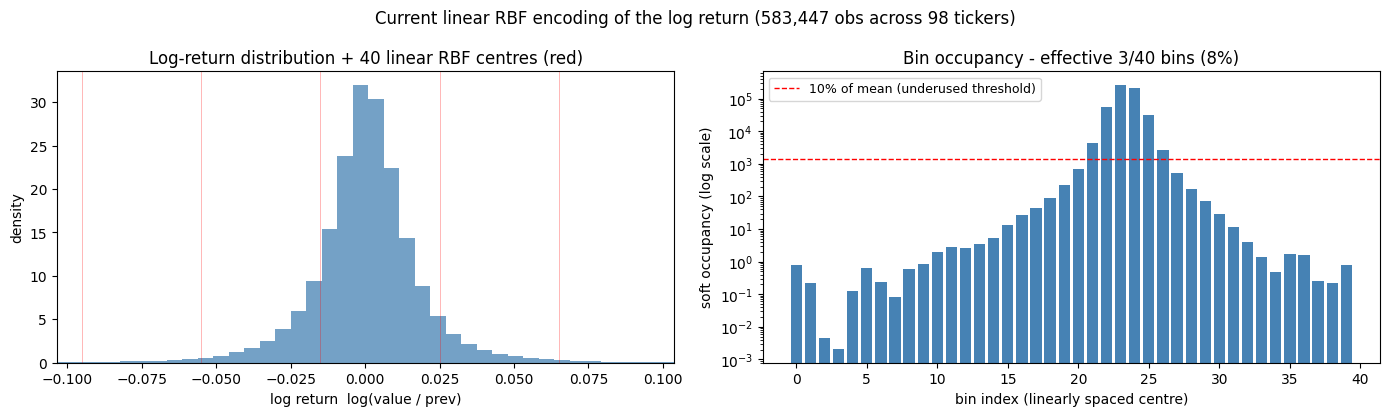

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.2))

# Left: log-return histogram with the linear bin centres overlaid.
axs[0].hist(all_log, bins=300, color="steelblue", alpha=0.75, density=True)
for c in lin_enc.centers:
    axs[0].axvline(c, color="red", lw=0.4, alpha=0.5)
axs[0].set_xlim(np.percentile(all_log, 0.2), np.percentile(all_log, 99.8))
axs[0].set_xlabel("log return  log(value / prev)")
axs[0].set_ylabel("density")
axs[0].set_title(f"Log-return distribution + {RETURN_NBIN} linear RBF centres (red)")

# Right: per-bin soft occupancy (log scale highlights the starved tail bins).
axs[1].bar(np.arange(RETURN_NBIN), occ_lin, color="steelblue")
axs[1].axhline(0.10 * occ_lin.mean(), color="red", ls="--", lw=1,
               label="10% of mean (underused threshold)")
axs[1].set_yscale("log")
axs[1].set_xlabel("bin index (linearly spaced centre)")
axs[1].set_ylabel("soft occupancy (log scale)")
axs[1].set_title(f"Bin occupancy - effective {stats_lin['effective_bins']:.0f}/{RETURN_NBIN} bins "
                 f"({stats_lin['utilization']:.0%})")
axs[1].legend(fontsize=9)

plt.suptitle(f"Current linear RBF encoding of the log return "
             f"({len(all_log):,} obs across {len(per_ticker)} tickers)", fontsize=12)
plt.tight_layout()
save_fig(fig, 1, "linear_encoder_distribution_occupancy")
plt.show()


## 2. Who uses the code space? Per-stock and per-sector volatility

A ticker's daily log-return volatility (its standard deviation) sets how widely its returns spread across the
bins: quiet names sit in a few central bins, while volatile names reach further into the tails and therefore
activate **more** of the available code space. We quantify this with the **effective bins used** per ticker
under the shared global linear encoder, then roll the same view up to GICS-style sectors.


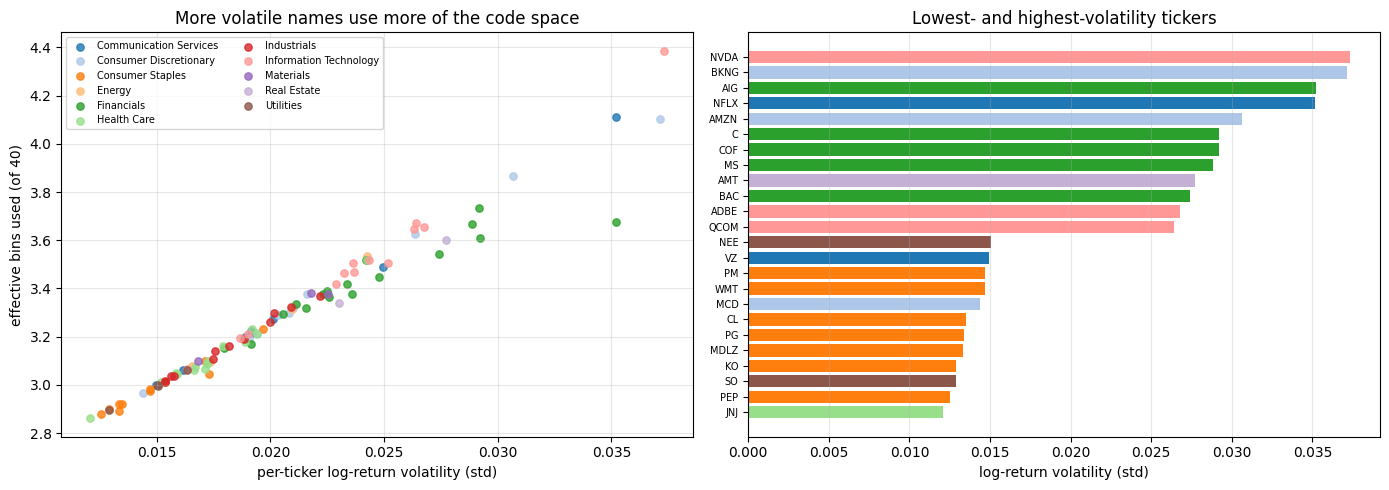

In [5]:
# GICS-style sector map for the SP100 names in this CSV. Anything unmapped -> "Other".
SECTORS = {
    "Information Technology": ["AAPL", "ADBE", "CSCO", "IBM", "INTC", "MSFT", "NVDA", "ORCL",
                                "QCOM", "TXN", "ACN", "CRM", "AVGO"],
    "Communication Services": ["CMCSA", "DIS", "GOOGL", "META", "NFLX", "T", "VZ", "CHTR"],
    "Financials":             ["AIG", "ALL", "AXP", "BAC", "BK", "BLK", "C", "COF", "GS", "JPM",
                                "MET", "MS", "USB", "WFC", "V", "MA", "PYPL"],
    "Health Care":            ["ABT", "AMGN", "BMY", "CVS", "DHR", "GILD", "JNJ", "LLY", "MDT",
                                "MRK", "PFE", "TMO", "UNH", "ABBV"],
    "Consumer Staples":       ["CL", "COST", "KO", "MO", "PEP", "PG", "WMT", "WBA", "MDLZ", "PM", "KHC"],
    "Consumer Discretionary": ["AMZN", "BKNG", "HD", "LOW", "MCD", "NKE", "SBUX", "TGT", "F", "GM"],
    "Energy":                 ["COP", "CVX", "SLB", "XOM"],
    "Industrials":            ["BA", "CAT", "EMR", "FDX", "GD", "GE", "HON", "LMT", "MMM", "RTX",
                                "UNP", "UPS"],
    "Materials":              ["DD", "LIN", "DOW"],
    "Utilities":              ["DUK", "EXC", "NEE", "SO"],
    "Real Estate":            ["AMT", "SPG"],
}
TICKER_SECTOR = {t: sec for sec, names in SECTORS.items() for t in names}
sector_of = lambda s: TICKER_SECTOR.get(s, "Other")

# Per-ticker volatility (std of log return) and effective bins used under the global linear encoder.
vol_by_ticker = {s: float(log_by_ticker[s].std()) for s in per_ticker}
eff_by_ticker = {s: utilization_stats(occupancy(lin_enc, log_by_ticker[s]))["effective_bins"]
                 for s in per_ticker}

syms = list(per_ticker.keys())
vols = np.array([vol_by_ticker[s] for s in syms])
effs = np.array([eff_by_ticker[s] for s in syms])
secs = np.array([sector_of(s) for s in syms])

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Left: volatility vs effective bins used, coloured by sector.
uniq_secs = sorted(set(secs))
cmap = plt.get_cmap("tab20")
sec_color = {sec: cmap(i % 20) for i, sec in enumerate(uniq_secs)}
for sec in uniq_secs:
    m = secs == sec
    axs[0].scatter(vols[m], effs[m], s=28, color=sec_color[sec], label=sec, alpha=0.8)
axs[0].set_xlabel("per-ticker log-return volatility (std)")
axs[0].set_ylabel("effective bins used (of %d)" % RETURN_NBIN)
axs[0].set_title("More volatile names use more of the code space")
axs[0].legend(fontsize=7, ncol=2)
axs[0].grid(alpha=0.3)

# Right: top/bottom 12 tickers by volatility.
order = np.argsort(vols)
pick = np.concatenate([order[:12], order[-12:]])
y = np.arange(len(pick))
axs[1].barh(y, vols[pick], color=[sec_color[secs[i]] for i in pick])
axs[1].set_yticks(y)
axs[1].set_yticklabels([syms[i] for i in pick], fontsize=7)
axs[1].set_xlabel("log-return volatility (std)")
axs[1].set_title("Lowest- and highest-volatility tickers")
axs[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
save_fig(fig, 2, "per_ticker_volatility_vs_codespace")
plt.show()


,sector,n_tickers,volatility,effective_bins,utilization
0,Real Estate,2,0.0255,3.5,8.7%
1,Financials,17,0.0249,3.4,8.6%
2,Information Technology,13,0.0247,3.5,8.8%
3,Consumer Discretionary,10,0.0240,3.4,8.6%
4,Communication Services,8,0.0217,3.3,8.3%
5,Energy,4,0.0200,3.3,8.1%
6,Materials,3,0.0198,3.3,8.1%
7,Industrials,12,0.0182,3.2,7.9%
8,Health Care,14,0.0176,3.1,7.8%
9,Consumer Staples,11,0.0150,3.0,7.5%


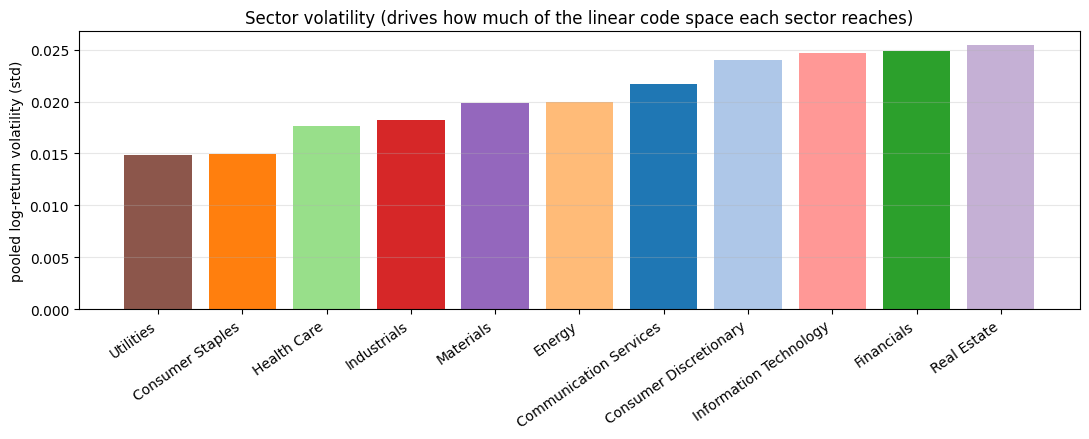

In [6]:
# Sector-level rollup: pooled volatility and effective code-space usage per sector.
rows = []
for sec in uniq_secs:
    members = [s for s in per_ticker if sector_of(s) == sec]
    pooled = np.concatenate([log_by_ticker[s] for s in members])
    occ_sec = occupancy(lin_enc, pooled)
    st = utilization_stats(occ_sec)
    rows.append((sec, len(members), float(pooled.std()),
                 st["effective_bins"], st["utilization"]))

sector_df = pd.DataFrame(rows, columns=["sector", "n_tickers", "volatility",
                                        "effective_bins", "utilization"]
                         ).sort_values("volatility", ascending=False).reset_index(drop=True)

# Plain formatted view (avoids the pandas Styler, which requires the optional jinja2 package).
sector_show = sector_df.copy()
sector_show["volatility"] = sector_show["volatility"].map("{:.4f}".format)
sector_show["effective_bins"] = sector_show["effective_bins"].map("{:.1f}".format)
sector_show["utilization"] = sector_show["utilization"].map("{:.1%}".format)
try:
    display(sector_show)
except NameError:
    print(sector_show.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
order = sector_df.sort_values("volatility").index
ax.bar(sector_df.loc[order, "sector"], sector_df.loc[order, "volatility"],
       color=[sec_color[s] for s in sector_df.loc[order, "sector"]])
ax.set_ylabel("pooled log-return volatility (std)")
ax.set_title("Sector volatility (drives how much of the linear code space each sector reaches)")
ax.tick_params(axis="x", rotation=35)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
save_fig(fig, 3, "sector_volatility")
plt.show()


## 3. Quantile coding: equalize the mass per bin

Quantile coding places the centres at the **empirical quantiles** of the log return instead of equally-spaced
points. Each adjacent pair of centres then brackets roughly the same number of observations, so the dense
centre of the distribution gets *fine* resolution and the sparse tails get *coarse* resolution - the opposite
of what the linear layout does. Because the quantile spacing is uneven, we give each centre an adaptive width
(`sigma` = local centre spacing) rather than one global sigma.

The prototype below mirrors `RBFBinner.Encoder1D`'s `encode`/`decode` interface so it is a drop-in candidate
if we decide to promote it. We compare **bin occupancy**, **effective bins**, and how many **centres fall in
the central 99% return range** (resolution where the data actually lives). Reconstruction RMSE is reported too,
but it is *not* a good resolution proxy: evenly-spaced linear centres reconstruct any in-range value almost
exactly via the Gaussian-weighted centroid property, no matter how starved those bins are.


In [7]:
class QuantileEncoder1D:
    """RBF encoder with centres at empirical quantiles and per-centre adaptive width.

    Drop-in compatible with RBFBinner.Encoder1D (``centers``, ``encode``, ``decode``).
    Centres sit at the *midpoint* quantiles ``(i+0.5)/n`` so equal mass falls in each bin
    without wasting the two outermost centres on the single most extreme observations.
    ``sigma_scale`` multiplies the local centre spacing used as each kernel's width.
    """

    def __init__(self, x, n_centers, sigma_scale=1.0):
        x = np.asarray(x, dtype=float)
        qs = (np.arange(n_centers) + 0.5) / n_centers   # midpoint quantiles
        self.centers = np.quantile(x, qs)
        # Adaptive width: half the distance to the neighbouring centres (endpoints one-sided).
        d = np.diff(self.centers)
        spacing = np.empty(n_centers)
        if n_centers > 2:
            spacing[1:-1] = 0.5 * (d[:-1] + d[1:])
            spacing[0], spacing[-1] = d[0], d[-1]
        else:
            spacing[:] = d.mean() if len(d) else 1.0
        pos = spacing[spacing > 0]
        spacing = np.where(spacing > 0, spacing, pos.min() if pos.size else 1.0)
        self.sigma = sigma_scale * spacing

    def encode(self, x):
        x = np.atleast_1d(np.asarray(x, dtype=float))
        diff = x[:, None] - self.centers[None, :]
        # Stable softmax: subtract the per-row max log-kernel so a far-tail point (whose
        # nearest narrow central kernel would otherwise underflow every column to 0) still
        # normalizes to the closest centre instead of producing 0/0 = NaN.
        log_phi = -0.5 * (diff / self.sigma[None, :]) ** 2
        log_phi -= log_phi.max(axis=1, keepdims=True)
        phi = np.exp(log_phi)
        phi /= np.sum(phi, axis=1, keepdims=True)
        return phi

    def decode(self, activations):
        activations = np.atleast_2d(activations)
        return activations @ self.centers


q_enc = QuantileEncoder1D(all_log, RETURN_NBIN)
occ_q = occupancy(q_enc, all_log)

print_stats("linear (current)", occ_lin)
print_stats("quantile", occ_q)


def decode_rmse(encoder, x):
    """Round-trip reconstruction RMSE in log space."""
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean((encoder.decode(encoder.encode(x)) - x) ** 2)))


def centres_in_central(encoder, x, pct=99.0):
    """How many centres land inside the central ``pct`` return range (resolution where data lives)."""
    lo, hi = np.percentile(x, [(100 - pct) / 2, 100 - (100 - pct) / 2])
    return int(np.sum((encoder.centers >= lo) & (encoder.centers <= hi)))


lo99, hi99 = np.percentile(all_log, [0.5, 99.5])
central = all_log[(all_log >= lo99) & (all_log <= hi99)]

print()
print(f"centres inside the central 99% range [{lo99:.3f}, {hi99:.3f}] (resolution where data lives):")
print(f"   linear   = {centres_in_central(lin_enc, all_log):2d}/{RETURN_NBIN}      "
      f"quantile = {centres_in_central(q_enc, all_log):2d}/{RETURN_NBIN}")
print()
print("decode round-trip RMSE (log space):")
print(f"   all data    linear = {decode_rmse(lin_enc, all_log):.5f}   quantile = {decode_rmse(q_enc, all_log):.5f}")
print(f"   central 99% linear = {decode_rmse(lin_enc, central):.5f}   quantile = {decode_rmse(q_enc, central):.5f}")
print()
print("Note: linear's tiny reconstruction RMSE is an artifact of evenly-spaced centres (the Gaussian-weighted")
print("centroid of symmetric centres ~= x for any in-range value), NOT usable resolution. Discriminability is")
print("set by how many *populated* centres cover the data - the effective-bins and centres-in-central-range")
print("numbers above - where quantile coding wins decisively.")


linear (current)        effective bins =    3.3/40  (utilization  8.2%)   underused = 85.0%   CV = 3.70
quantile                effective bins =   37.9/40  (utilization 94.7%)   underused =  0.0%   CV = 0.37

centres inside the central 99% range [-0.076, 0.076] (resolution where data lives):
   linear   =  4/40      quantile = 40/40

decode round-trip RMSE (log space):
   all data    linear = 0.00007   quantile = 0.00842
   central 99% linear = 0.00006   quantile = 0.00374

Note: linear's tiny reconstruction RMSE is an artifact of evenly-spaced centres (the Gaussian-weighted
centroid of symmetric centres ~= x for any in-range value), NOT usable resolution. Discriminability is
set by how many *populated* centres cover the data - the effective-bins and centres-in-central-range
numbers above - where quantile coding wins decisively.


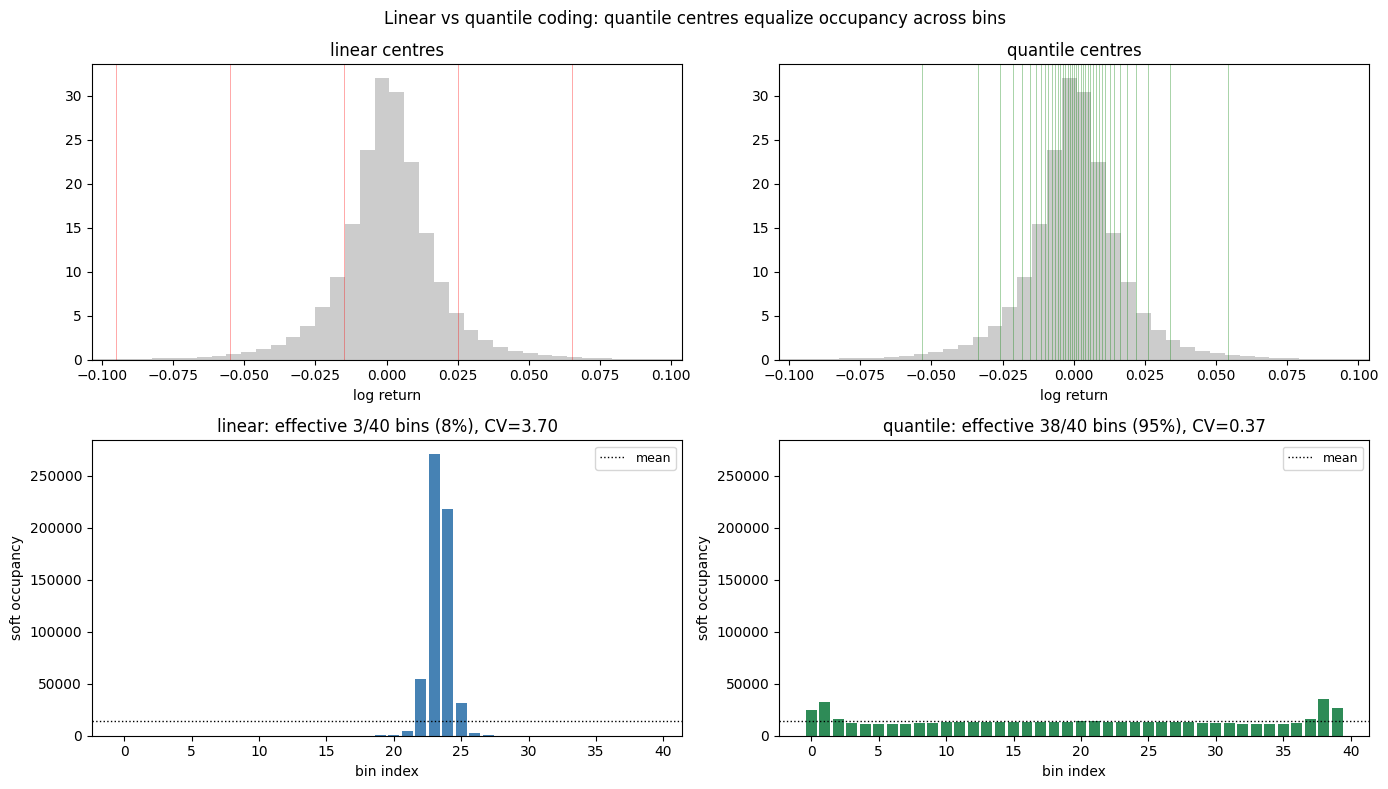

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Top row: centre placement on the distribution.
for ax, enc, name, color in [(axs[0, 0], lin_enc, "linear", "red"),
                             (axs[0, 1], q_enc, "quantile", "green")]:
    ax.hist(all_log, bins=300, color="0.8", density=True)
    for c in enc.centers:
        ax.axvline(c, color=color, lw=0.4, alpha=0.6)
    ax.set_xlim(np.percentile(all_log, 0.2), np.percentile(all_log, 99.8))
    ax.set_xlabel("log return")
    ax.set_title(f"{name} centres")

# Bottom row: occupancy per bin (shared linear y so the contrast is obvious).
ymax = max(occ_lin.max(), occ_q.max()) * 1.05
for ax, occ, name, color, st in [(axs[1, 0], occ_lin, "linear", "steelblue", stats_lin),
                                 (axs[1, 1], occ_q, "quantile", "seagreen",
                                  utilization_stats(occ_q))]:
    ax.bar(np.arange(RETURN_NBIN), occ, color=color)
    ax.axhline(occ.mean(), color="k", ls=":", lw=1, label="mean")
    ax.set_ylim(0, ymax)
    ax.set_xlabel("bin index")
    ax.set_ylabel("soft occupancy")
    ax.set_title(f"{name}: effective {st['effective_bins']:.0f}/{RETURN_NBIN} bins "
                 f"({st['utilization']:.0%}), CV={st['cv']:.2f}")
    ax.legend(fontsize=9)

plt.suptitle("Linear vs quantile coding: quantile centres equalize occupancy across bins", fontsize=12)
plt.tight_layout()
save_fig(fig, 4, "linear_vs_quantile_occupancy")
plt.show()


## 4. Extreme outliers: drop / clip the tails?

Log-return tails are extreme (single-day crashes, gaps, post-IPO jumps). They drag the **linear** encoder's
`[min, max]` range outward, which is exactly why the central bins are starved. Two questions:

- *How much* utilization do we recover by winsorizing the tails before fitting the encoder — lightly at **0.5%**
  per side, or more aggressively at **3%**?
- Quantile coding is far less sensitive to the absolute range, so how much does trimming matter for it?

Below we compare policies on the **linear** encoder (the one that suffers most): keep everything,
**winsorize** (clip) to the chosen percentiles, or **drop** the outer 3% entirely. We also show the quantile
encoder for reference. Note the trade-off: clipping/dropping discards genuine large moves, which may carry
signal (volatility regime, crash risk) we care about downstream - so a tail-aware alternative is to keep them
but reserve a couple of dedicated wide tail bins.


In [9]:
def winsor_bounds(x, tail_pct):
    """Return the lower/upper cut points for symmetric ``tail_pct`` winsorization."""
    return np.percentile(x, [tail_pct, 100.0 - tail_pct])


def linear_winsor_encoder(x, tail_pct, nbin, sigma):
    """Fit a linear RBF encoder on the ``tail_pct`` winsor range; return clipped data for occupancy."""
    lo, hi = winsor_bounds(x, tail_pct)
    clipped = np.clip(x, lo, hi)
    enc = RBFBinner.Encoder1D.from_linear_winsor(x, nbin, tail_pct, sigma)
    return enc, clipped, lo, hi


# 0.5% winsor (production binmode=rbf default).
lin_clip05, clipped05, lo05, hi05 = linear_winsor_encoder(
    all_log, FG.RBF_WINSOR_TAIL_PCT, RETURN_NBIN, SIGMA)
print(f"0.5% / 99.5% log-return cut points: [{lo05:.4f}, {hi05:.4f}]  "
      f"(linear full range was [{all_log.min():.3f}, {all_log.max():.3f}])")

# 3% policies (winsorize or drop) for comparison.
LO_PCT, HI_PCT = 3.0, 97.0
lo, hi = winsor_bounds(all_log, LO_PCT)
print(f"3% / 97% log-return cut points: [{lo:.4f}, {hi:.4f}]")

clipped = np.clip(all_log, lo, hi)                      # winsorize
kept = all_log[(all_log >= lo) & (all_log <= hi)]       # drop outer 3%

# Linear encoders fit to each policy's range; quantile fit to the kept data.
lin_full = RBFBinner.Encoder1D(all_log.min(), all_log.max(), RETURN_NBIN, SIGMA)  # legacy raw min/max
lin_clip = RBFBinner.Encoder1D(lo, hi, RETURN_NBIN, SIGMA)
lin_drop = RBFBinner.Encoder1D(kept.min(), kept.max(), RETURN_NBIN, SIGMA)
q_drop = QuantileEncoder1D(kept, RETURN_NBIN)

print()
print_stats("linear  full", occupancy(lin_full, all_log))
print_stats("linear  winsorized 0.5%", occupancy(lin_clip05, clipped05))
print_stats("linear  winsorized 3%", occupancy(lin_clip, clipped))
print_stats("linear  dropped 3%", occupancy(lin_drop, kept))
print_stats("quantile full", occ_q)
print_stats("quantile dropped 3%", occupancy(q_drop, kept))


0.5% / 99.5% log-return cut points: [-0.0760, 0.0757]  (linear full range was [-0.936, 0.626])
3% / 97% log-return cut points: [-0.0375, 0.0373]

linear  full            effective bins =    3.3/40  (utilization  8.2%)   underused = 85.0%   CV = 3.70
linear  winsorized 0.5%  effective bins =   31.0/40  (utilization 77.5%)   underused =  0.0%   CV = 0.69
linear  winsorized 3%   effective bins =   39.0/40  (utilization 97.6%)   underused =  0.0%   CV = 0.22
linear  dropped 3%      effective bins =   38.8/40  (utilization 97.0%)   underused =  0.0%   CV = 0.24
quantile full           effective bins =   37.9/40  (utilization 94.7%)   underused =  0.0%   CV = 0.37
quantile dropped 3%     effective bins =   39.8/40  (utilization 99.6%)   underused =  0.0%   CV = 0.09


{'n_bins': 40,
 'effective_bins': 39.83672579791749,
 'utilization': 0.9959181449479372,
 'underused_frac': 0.0,
 'cv': 0.09371367657561168}

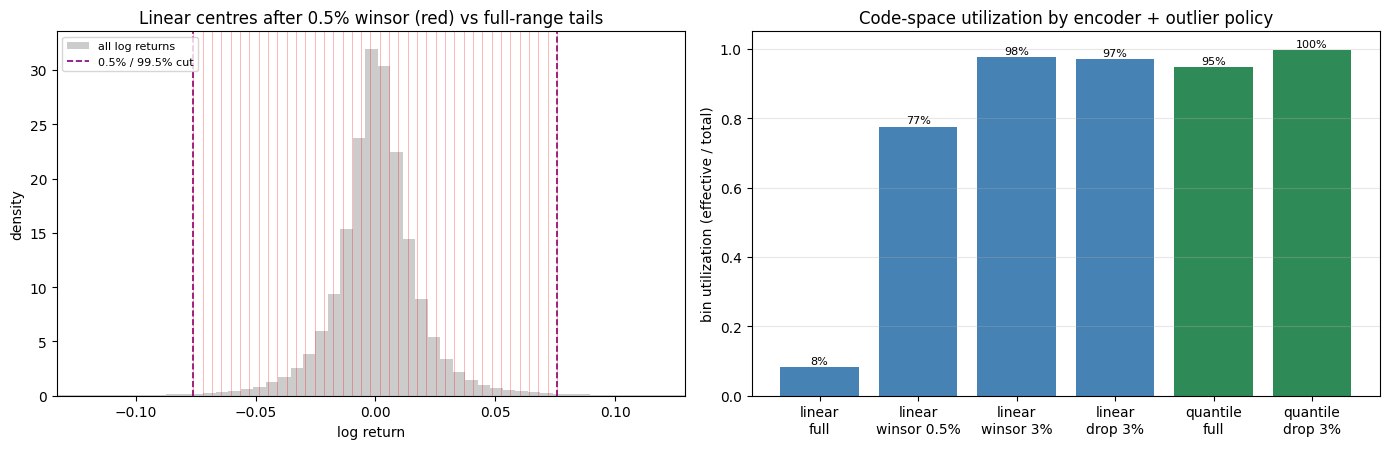

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.6))

# Left: distribution with the 0.5% winsor cut lines and the rescaled linear centres.
axs[0].hist(all_log, bins=300, color="0.8", density=True, label="all log returns")
axs[0].axvline(lo05, color="purple", ls="--", lw=1.2, label="0.5% / 99.5% cut")
axs[0].axvline(hi05, color="purple", ls="--", lw=1.2)
for c in lin_clip05.centers:
    axs[0].axvline(c, color="red", lw=0.4, alpha=0.5)
axs[0].set_xlim(np.percentile(all_log, 0.1), np.percentile(all_log, 99.9))
axs[0].set_xlabel("log return")
axs[0].set_ylabel("density")
axs[0].set_title("Linear centres after 0.5% winsor (red) vs full-range tails")
axs[0].legend(fontsize=8)

# Right: utilization recovered by each policy.
labels = [
    "linear\nfull",
    "linear\nwinsor 0.5%",
    "linear\nwinsor 3%",
    "linear\ndrop 3%",
    "quantile\nfull",
    "quantile\ndrop 3%",
]
util = [
    utilization_stats(occupancy(lin_full, all_log))["utilization"],
    utilization_stats(occupancy(lin_clip05, clipped05))["utilization"],
    utilization_stats(occupancy(lin_clip, clipped))["utilization"],
    utilization_stats(occupancy(lin_drop, kept))["utilization"],
    utilization_stats(occ_q)["utilization"],
    utilization_stats(occupancy(q_drop, kept))["utilization"],
]
colors = ["steelblue"] * 4 + ["seagreen"] * 2
axs[1].bar(labels, util, color=colors)
for i, u in enumerate(util):
    axs[1].text(i, u + 0.01, f"{u:.0%}", ha="center", fontsize=8)
axs[1].set_ylim(0, 1.05)
axs[1].set_ylabel("bin utilization (effective / total)")
axs[1].set_title("Code-space utilization by encoder + outlier policy")
axs[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
save_fig(fig, 5, "outlier_policy_utilization")
plt.show()


## 5. Takeaways

- **The linear encoder is under-utilized.** With the production `return_nbin`, only a fraction of the bins
  carry meaningful occupancy; the tail bins are starved while the dense centre is coarsely resolved (section 1).
- **Volatility decides code-space usage.** More volatile tickers and sectors (Tech / Communication Services,
  and high-beta names) reach further into the tails and activate more bins; quiet staples/utilities sit in a
  few central bins (section 2). A single global linear layout therefore serves the cross-section unevenly.
- **Quantile coding equalizes occupancy.** Centres at midpoint quantiles lift effective-bin utilization from
  ~7% (≈4/50 bins) to ~95% (≈47/50 bins) and collapse the occupancy CV, placing ~49/50 centres inside the
  central 99% return range versus only ~5 for the linear layout - i.e. fine resolution exactly where the data
  lives (section 3). Its slightly larger reconstruction RMSE is not a real cost: linear's near-zero RMSE is an
  artifact of evenly-spaced centres, not usable resolution.
- **Outliers.** Even a light **0.5%** linear winsor helps pull centres back toward the bulk of the data, but
  aggressive **3%** winsor/drop is needed to reach ~95% utilization on the linear encoder. Quantile coding is
  range-robust by construction (section 4), so trimming barely matters for it. Since extreme moves may carry
  downstream signal, the cleaner path is quantile coding **without** discarding tails - optionally with a couple
  of reserved wide tail bins - rather than clipping data we might later want.

**Conclusion.** Add a quantile mode to `RBFBinner.Encoder1D` (as a sibling encoder) to fit centres on quantiles of the pooled log return. Keep the raw tails (no clipping) and revisit dedicated tail bins only if the extreme-move resolution proves too coarse. This is a drop-in change:
the decode path and `delog_primary` display mapping are unaffected because the encoder interface stays the same.
